## **Notebook 4 - Deep Learning using LSTM**

In this notebook, we implement a Deep Learning model (LSTM) using the preprocessed dataset.

#### Objectives:
- Use prepared train and test datasets
- Convert text into sequences
- Train an LSTM model
- Evaluate performance and compare with ML models

This notebook focuses only on Deep Learning without repeating preprocessing steps.

#### **Import Required Libraries**

In [49]:
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt


import tensorflow as tf
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

#### **Logger Configuration**

This project uses Python logging instead of print statements.

Why?
- Debugging large datasets
- Tracking preprocessing steps
- Production ML pipelines
- Helps identify where a failure occurred

All activities will be recorded inside:
`deep_learning_lstm.log`

In [50]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
LOG_DIR = PROJECT_ROOT / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

LOG_FILE = LOG_DIR / "deep_learning_lstm.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE, mode="a", encoding="utf-8")
    ],
    force=True
)

logger = logging.getLogger(__name__)

logger.info("==== DEEP LEARNING LSTM PIPELINE STARTED ====")
print(f"Logging to: {LOG_FILE}")

Logging to: E:\DData\Projects\DSC\NextHikes\Python\disaster-tweet-classification-nlp-pro-7\logs\deep_learning_lstm.log


#### **Load Dataset**

In [51]:
logger.info("Loading dataset for deep learning LSTM...")
train_df = pd.read_csv("../data/train_dataset_prepared.csv")
test_df = pd.read_csv("../data/test_dataset_prepared.csv")
logger.info("Dataset for deep learning LSTM loaded successfully.")
train_df.head()

,text,clean_text,target
0,Sassy city girl country hunk stranded in Smoky...,sassy city girl country hunk stranded in smoky...,1
1,God's Kingdom (Heavenly Gov't) will rule over ...,gods kingdom heavenly govt will rule over all ...,0
2,Mopheme and Bigstar Johnson are a problem in t...,mopheme and bigstar johnson are a problem in t...,0
3,@VixMeldrew sounds like a whirlwind life!,sounds like a whirlwind life,0
4,Malaysia confirms plane debris washed up on Re...,malaysia confirms plane debris washed up on re...,1


---

#### **Define Features and Target**

In [52]:
logger.info("Preparing data for deep learning LSTM...")
X_train = train_df["clean_text"]
y_train = train_df["target"]

X_test = test_df["clean_text"]
y_test = test_df["target"]
logger.info("Data for deep learning LSTM prepared successfully.")

---
#### **Tokenization**

Convert text into sequences for LSTM input.

In [53]:
logger.info("Tokenizing and padding sequences for deep learning LSTM...")
vocab_size = 10000
max_len = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
logger.info(
    f"Tokenization completed successfully. "
    f"train_sequences={len(X_train_seq)}, "
    f"test_sequences={len(X_test_seq)}, "
    f"first_train_seq_len={len(X_train_seq[0]) if X_train_seq else 0}, "
    f"first_test_seq_len={len(X_test_seq[0]) if X_test_seq else 0}"
)
print(
    f"Tokenization completed successfully. "
    f"train_sequences={len(X_train_seq)}, "
    f"test_sequences={len(X_test_seq)}, "
    f"first_train_seq_len={len(X_train_seq[0]) if X_train_seq else 0}, "
    f"first_test_seq_len={len(X_test_seq[0]) if X_test_seq else 0}"
)
X_train_seq
X_test_seq

Tokenization completed successfully. train_sequences=6090, test_sequences=1523, first_train_seq_len=13, first_test_seq_len=10


[[6742, 62, 49, 16, 163, 4044, 1, 90, 2, 1],
 [2323,
  1572,
  110,
  87,
  17,
  1995,
  36,
  678,
  47,
  1432,
  171,
  6,
  2886,
  25,
  1995,
  36,
  3731,
  71],
 [64, 266, 363, 616, 2, 58, 4, 112, 456, 1],
 [329, 4350, 2646, 4351, 1276, 2510, 6, 4352, 4353, 586],
 [241,
  12,
  894,
  26,
  25,
  3,
  9550,
  894,
  26,
  1198,
  34,
  3448,
  1,
  31,
  34,
  1804,
  1,
  12,
  384,
  26],
 [912, 292, 52, 372, 1004, 375, 4, 1005, 2, 912, 292, 52, 372, 1004, 1],
 [1, 645, 9301, 825, 1, 1, 447],
 [7, 100, 400, 13, 1, 63, 106, 64, 5, 3642],
 [571, 1, 22, 581, 52, 2, 1087],
 [2, 1, 522, 7, 69, 10, 1, 27, 86, 1, 4, 3, 490, 98, 10, 1, 8, 1, 1756],
 [1637, 2, 108, 35, 83],
 [1, 399, 1, 974, 1, 211, 4097, 1097, 1642, 1, 23, 1, 2693],
 [439, 1, 9, 1496, 5, 2, 242, 4, 2, 1431, 937],
 [47, 141, 230, 1, 4, 2, 2983, 255, 2, 577, 4002, 15, 79, 148],
 [46, 1169, 5975, 25, 1461, 2939, 1042, 365, 494, 3, 1, 17, 83, 92],
 [3177, 4, 2, 967, 6, 1, 1, 5, 112, 1, 133, 903, 5, 69, 1, 1],
 [15, 274,

---
#### **Padding**
Padding Sequences

In [54]:
logger.info("Starting padding sequences for deep learning LSTM...")
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")
logger.info(f"Padding completed successfully. X_train_pad_shape={X_train_pad.shape}, X_test_pad_shape={X_test_pad.shape}")
print(f"Padding completed successfully. X_train_pad_shape={X_train_pad.shape}, X_test_pad_shape={X_test_pad.shape}")
X_train_pad
X_test_pad

Padding completed successfully. X_train_pad_shape=(6090, 100), X_test_pad_shape=(1523, 100)


array([[6742,   62,   49, ...,    0,    0,    0],
       [2323, 1572,  110, ...,    0,    0,    0],
       [  64,  266,  363, ...,    0,    0,    0],
       ...,
       [ 628,   15, 1912, ...,    0,    0,    0],
       [ 144,    7,   69, ...,    0,    0,    0],
       [ 448, 1247,    1, ...,    0,    0,    0]],
      shape=(1523, 100), dtype=int32)

---

#### **Build LSTM Model**

In [55]:
logger.info("Building LSTM model for deep learning...")
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])
logger.info(
    f"LSTM model built successfully. vocab_size={vocab_size}, "
    f"max_len={max_len}, embedding_dim=64, lstm_units=64, "
    f"dropout_rate=0.5, dense_units=32, output_units=1"
)
print(
    f"LSTM model built successfully. vocab_size={vocab_size}, "
    f"max_len={max_len}, embedding_dim=64, lstm_units=64, "
    f"dropout_rate=0.5, dense_units=32, output_units=1"
)
model.summary()

LSTM model built successfully. vocab_size=10000, max_len=100, embedding_dim=64, lstm_units=64, dropout_rate=0.5, dense_units=32, output_units=1


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---
#### **Compile Model**

In [56]:
logger.info("Starting compilation of LSTM model for deep learning...")
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
logger.info("LSTM model compiled successfully. loss=binary_crossentropy, optimizer=adam, metrics=['accuracy'], output_activation=sigmoid, task=binary_classification")

---

#### **Train Model**

In [57]:
logger.info("Starting training of LSTM model for deep learning...")
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)
logger.info(f"LSTM model training completed successfully. epochs={len(history.history['loss'])}, final_train_loss={history.history['loss'][-1]:.4f}, final_train_accuracy={history.history['accuracy'][-1]:.4f}, final_val_loss={history.history['val_loss'][-1]:.4f}, final_val_accuracy={history.history['val_accuracy'][-1]:.4f}")

Epoch 1/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5665 - loss: 0.6861 - val_accuracy: 0.5739 - val_loss: 0.6822
Epoch 2/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5698 - loss: 0.6851 - val_accuracy: 0.5739 - val_loss: 0.6828
Epoch 3/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5694 - loss: 0.6849 - val_accuracy: 0.5739 - val_loss: 0.6827
Epoch 4/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5694 - loss: 0.6842 - val_accuracy: 0.5739 - val_loss: 0.6840
Epoch 5/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5694 - loss: 0.6846 - val_accuracy: 0.5739 - val_loss: 0.6825


---

#### **Model Evaluation**

In [58]:
logger.info("Starting evaluation of LSTM model for deep learning...")
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)
loss, accuracy = model.evaluate(X_test_pad, y_test)
print(classification_report(y_test, y_pred))
logger.info(
    f"LSTM model evaluation completed successfully. "
    f"test_loss={loss:.4f}, "
    f"test_accuracy={accuracy:.4f}, "
    f"evaluation_samples={len(X_test_pad)}"
)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5706 - loss: 0.6833
              precision    recall  f1-score   support

           0       0.57      1.00      0.73       869
           1       0.00      0.00      0.00       654

    accuracy                           0.57      1523
   macro avg       0.29      0.50      0.36      1523
weighted avg       0.33      0.57      0.41      1523



c:\Users\Aishwarya Kr Singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Aishwarya Kr Singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Aishwarya Kr Singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

---

#### **F1 Score**

In [59]:
logger.info("Calculating F1-score for LSTM model...")
lstm_f1 = f1_score(y_test, y_pred)
logger.info(f"LSTM model F1-score calculated successfully. lstm_f1={lstm_f1:.4f}")
print(f"LSTM model F1-score: {lstm_f1:.4f}")

LSTM model F1-score: 0.0000


---

#### **Saving Model**

In [60]:
logger.info("Saving LSTM model for deep learning...")
model.save("../models/lstm_model.h5")
logger.info("LSTM model saved successfully to ../models/lstm_model.h5")

---

#### **Training Performance**

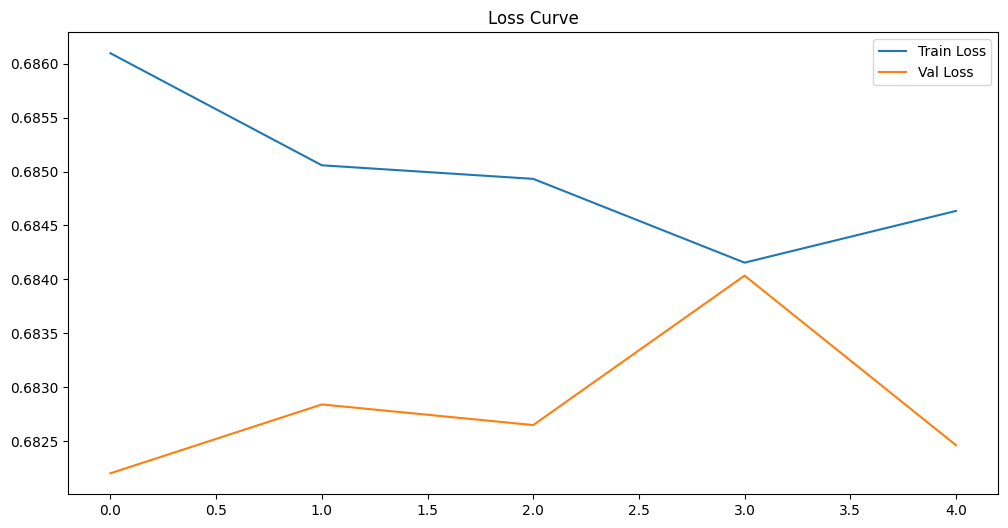

In [62]:
logger.info("Plotting loss curve for LSTM model...")
plt.figure(figsize=(12, 6))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")

plt.legend()
plt.title("Loss Curve")
plt.show()
logger.info("Loss curve plotted successfully.")
logger.info("==== DEEP LEARNING LSTM PIPELINE COMPLETED ====")

---

### **Summary**

In this notebook, we implemented a Deep Learning model using LSTM on preprocessed data.

#### Key Points:

- Used already prepared train/test datasets (no duplication)
- Converted text into sequences using Tokenizer
- Built and trained an LSTM model
- Evaluated using classification metrics

#### Observations:

- LSTM captures sequential relationships in text
- Performance depends on data size and tuning
- Provides deeper contextual understanding than TF-IDF

#### Conclusion

This notebook complements traditional ML models by introducing a sequence-based Deep Learning approach for text classification.

#### Next Step

Compare ML and LSTM models in final evaluation notebook.